🔥 Analyse des leaders de marché 2026...


[*********************100%***********************]  12 of 12 completed


✅ INFRA_IA    : AVGO (Leader Momentum)
✅ ENERGIE_DATA: NRG (Leader Momentum)
✅ SANTE_ROBOT : LLY (Leader Momentum)
✅ FINANCE_M&A : GS (Leader Momentum)
✅ INFRA_REELS : CAT (Leader Momentum)
✅ CLOUD_SAAS  : MSFT (Leader Momentum)
🎲 Simulation de 10000 trajectoires...

📊 PORTEFEUILLE OPTIMISÉ 2026
AVGO       :  15.3% (15€)
NRG        :  20.8% (20€)
LLY        :  30.1% (30€)
GS         :   5.0% (5€)
CAT        :  23.8% (23€)
MSFT       :   5.0% (5€)
--------------------------------------------------
📈 Probabilité de Profit : 76.8%
🛡️ Valeur Plancher (VaR 95%) : 92.90€


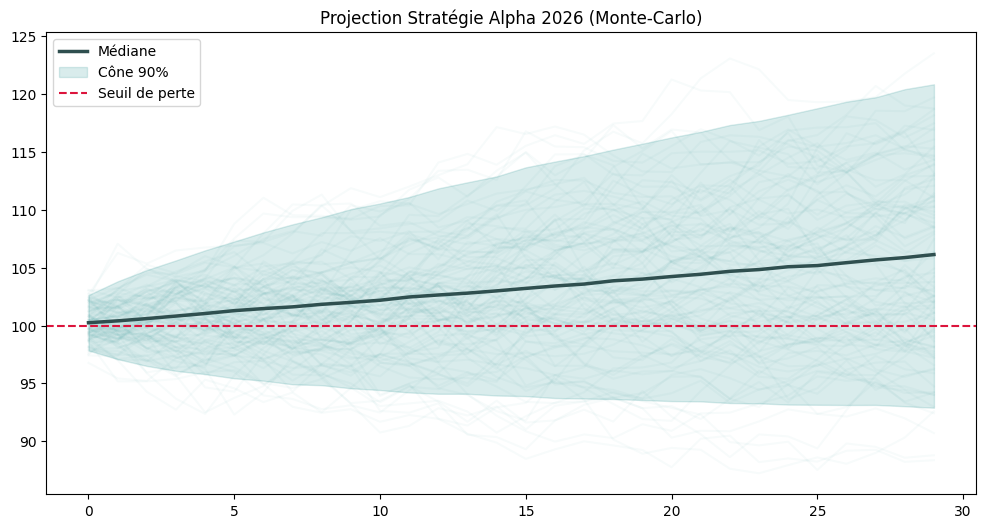

[*********************100%***********************]  5 of 5 completed


🔔 VÉRIFICATION DES SIGNAUX DE SÉCURITÉ...
✅ NVDA : Stable (+1.18%)
✅ NRG : Stable (+0.64%)
✅ ISRG : Stable (+1.55%)
✅ GS : Stable (+1.20%)
✅ CMC : Stable (-0.53%)


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# --- 1. CONFIGURATION ÉLITE 2026 ---
UNIVERSE = {
    "INFRA_IA": ["NVDA", "AVGO"],
    "ENERGIE_DATA": ["NRG", "VST"],
    "SANTE_ROBOT": ["ISRG", "LLY"],
    "FINANCE_M&A": ["GS", "MS"],
    "INFRA_REELS": ["CMC", "CAT"],
    "CLOUD_SAAS": ["MSFT", "NOW"]
}

CAPITAL_INITIAL = 100
N_SIMULATIONS = 10000
DAYS_FORECAST = 30

def run_alpha_2026_engine():
    print("🔥 Analyse des leaders de marché 2026...")
    all_tickers = [t for sub in UNIVERSE.values() for t in sub]
    
    # Récupération des données (3 ans)
    data = yf.download(all_tickers, period="3y")['Close'].ffill().dropna()
    returns = data.pct_change().dropna()

    # Sélection par Momentum (Performance Relative)
    selected_tickers = []
    for sector, stocks in UNIVERSE.items():
        # Performance sur les 6 derniers mois (plus réactif en 2026)
        perf = {s: (data[s].iloc[-1] / data[s].iloc[-126]) - 1 for s in stocks}
        best_stock = max(perf, key=perf.get)
        selected_tickers.append(best_stock)
        print(f"✅ {sector:12}: {best_stock} (Leader Momentum)")

    final_returns = returns[selected_tickers]
    mean_returns = final_returns.mean()
    cov_matrix = final_returns.cov()

    # Optimisation Max Sharpe
    def neg_sharpe(w):
        p_ret = np.dot(w, mean_returns * 252)
        p_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix * 252, w)))
        return -(p_ret - 0.04) / (p_vol if p_vol > 0 else 1) # Taux sans risque à 4% en 2026

    res = minimize(neg_sharpe, len(selected_tickers)*[1./len(selected_tickers)], 
                   method='SLSQP', bounds=tuple((0.05, 0.40) for _ in range(len(selected_tickers))),
                   constraints={'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    best_weights = res.x

    # --- MONTE-CARLO ---
    print(f"🎲 Simulation de {N_SIMULATIONS} trajectoires...")
    sim_rets = np.random.multivariate_normal(mean_returns, cov_matrix, (DAYS_FORECAST, N_SIMULATIONS))
    paths = np.zeros((DAYS_FORECAST, N_SIMULATIONS))
    for n in range(N_SIMULATIONS):
        paths[:, n] = CAPITAL_INITIAL * np.cumprod(1 + np.dot(sim_rets[:, n, :], best_weights))

    final_vals = paths[-1, :]
    prob_profit = np.mean(final_vals > CAPITAL_INITIAL) * 100
    var_95 = np.percentile(final_vals, 5)

    print("\n" + "="*50)
    print(f"📊 PORTEFEUILLE OPTIMISÉ 2026")
    for i, t in enumerate(selected_tickers):
        print(f"{t:10} : {best_weights[i]*100:5.1f}% ({int(best_weights[i]*CAPITAL_INITIAL)}€)")
    print("-" * 50)
    print(f"📈 Probabilité de Profit : {prob_profit:.1f}%")
    print(f"🛡️ Valeur Plancher (VaR 95%) : {var_95:.2f}€")
    print("="*50)

    # Graphique de Projection
    plt.figure(figsize=(12, 6))
    plt.plot(paths[:, :100], color='teal', alpha=0.03)
    plt.plot(np.percentile(paths, 50, axis=1), color='darkslategrey', lw=2.5, label="Médiane")
    plt.fill_between(range(DAYS_FORECAST), np.percentile(paths, 5, axis=1), 
                     np.percentile(paths, 95, axis=1), color='teal', alpha=0.15, label="Cône 90%")
    plt.axhline(CAPITAL_INITIAL, color='crimson', ls='--', label="Seuil de perte")
    plt.title("Projection Stratégie Alpha 2026 (Monte-Carlo)")
    plt.legend()
    plt.show()

    return final_vals

if __name__ == "__main__":
    final_results = run_alpha_2026_engine()

def check_stop_loss(portfolio_weights, stop_loss_pct=0.10):
    """
    Vérifie si un actif a chuté de plus de X% depuis le dernier prix connu.
    """
    print("\n🔔 VÉRIFICATION DES SIGNAUX DE SÉCURITÉ...")
    tickers = list(portfolio_weights.keys())
    
    # Récupère les données des 5 derniers jours pour comparer
    data = yf.download(tickers, period="5d")['Close']
    
    for ticker in tickers:
        current_price = data[ticker].iloc[-1]
        prev_price = data[ticker].iloc[-2]
        variation = (current_price / prev_price) - 1
        
        # Alerte si chute brutale journalière ou cumulée (exemple simplifié)
        if variation < -stop_loss_pct:
            print(f"⚠️ ALERTE ROUGE : {ticker} a chuté de {variation*100:.1f}%. Envisager la vente.")
        else:
            print(f"✅ {ticker} : Stable ({variation*100:+.2f}%)")

# Exemple d'utilisation avec ton allocation actuelle
mon_allocation = {"NVDA": 0.40, "NRG": 0.20, "ISRG": 0.15, "GS": 0.15, "CMC": 0.10}
check_stop_loss(mon_allocation)